# 03 — Create Gold Tables

Load silver stock price data and build analytics-ready gold tables.

**Gold outputs:**
- `gold_stock_prices.csv` — one row per ticker with returns, volatility, and volume averages
- `gold_moving_averages.csv` — daily prices with 20-day and 50-day moving averages
- `gold_volume_summary.csv` — one row per ticker with volume stats

**Flow:** silver CSV → gold metrics → inspect → save gold CSVs

**Prerequisite:** Run `02_clean_silver.ipynb` first so `data/processed/silver/silver_stock_prices.csv` exists.

## Setup

Add `src` to the Python path and import the gold metrics helpers.

In [1]:
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"
SILVER_INPUT_PATH = PROJECT_ROOT / "data" / "processed" / "silver" / "silver_stock_prices.csv"
GOLD_OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / "gold"

PERFORMANCE_OUTPUT_PATH = GOLD_OUTPUT_DIR / "gold_stock_prices.csv"
MOVING_AVERAGES_OUTPUT_PATH = GOLD_OUTPUT_DIR / "gold_moving_averages.csv"
VOLUME_SUMMARY_OUTPUT_PATH = GOLD_OUTPUT_DIR / "gold_volume_summary.csv"

sys.path.insert(0, str(SRC_DIR))

from metrics import (
    create_gold_moving_averages,
    create_gold_performance_summary,
    create_gold_volume_summary,
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Silver input: {SILVER_INPUT_PATH}")
print(f"Gold output dir: {GOLD_OUTPUT_DIR}")

Project root: C:\Users\bruce\OneDrive\Desktop\School\Personal Projects\financial-market-analytics-warehouse
Silver input: C:\Users\bruce\OneDrive\Desktop\School\Personal Projects\financial-market-analytics-warehouse\data\processed\silver\silver_stock_prices.csv
Gold output dir: C:\Users\bruce\OneDrive\Desktop\School\Personal Projects\financial-market-analytics-warehouse\data\processed\gold


## Load silver data

Read the cleaned silver file created by the silver notebook.

In [2]:
if not SILVER_INPUT_PATH.exists():
    raise FileNotFoundError(
        f"Silver file not found at {SILVER_INPUT_PATH}. Run 02_clean_silver.ipynb first."
    )

silver_df = pd.read_csv(SILVER_INPUT_PATH, parse_dates=["date", "loaded_at"])

print(f"Silver rows: {len(silver_df):,}")
print(f"Tickers: {sorted(silver_df['ticker'].unique())}")
silver_df.head()

Silver rows: 210
Tickers: ['AAPL', 'MSFT']


,date,ticker,open,high,low,close,adj_close,volume,daily_return,dollar_volume,source,loaded_at
0,2024-01-02,AAPL,187.149994,188.440002,183.889999,185.639999,183.562164,82488700,NaN,1.531320e+10,AAPL.csv,2026-06-22 21:05:32.981723+00:00
1,2024-01-03,AAPL,184.220001,185.880005,183.429993,184.250000,182.187744,58414500,-0.007487,1.076287e+10,AAPL.csv,2026-06-22 21:05:32.981723+00:00
2,2024-01-04,AAPL,182.149994,183.089996,180.880005,181.910004,179.873932,71983600,-0.012700,1.309454e+10,AAPL.csv,2026-06-22 21:05:32.981723+00:00
3,2024-01-05,AAPL,181.990005,182.759995,180.169998,181.179993,179.152100,62379700,-0.004013,1.130195e+10,AAPL.csv,2026-06-22 21:05:32.981723+00:00
4,2024-01-08,AAPL,182.089996,185.600006,181.500000,185.559998,183.483063,59144500,0.024175,1.097485e+10,AAPL.csv,2026-06-22 21:05:32.981723+00:00


## Stock price line chart

Plot close price over time for every ticker in the dataset.

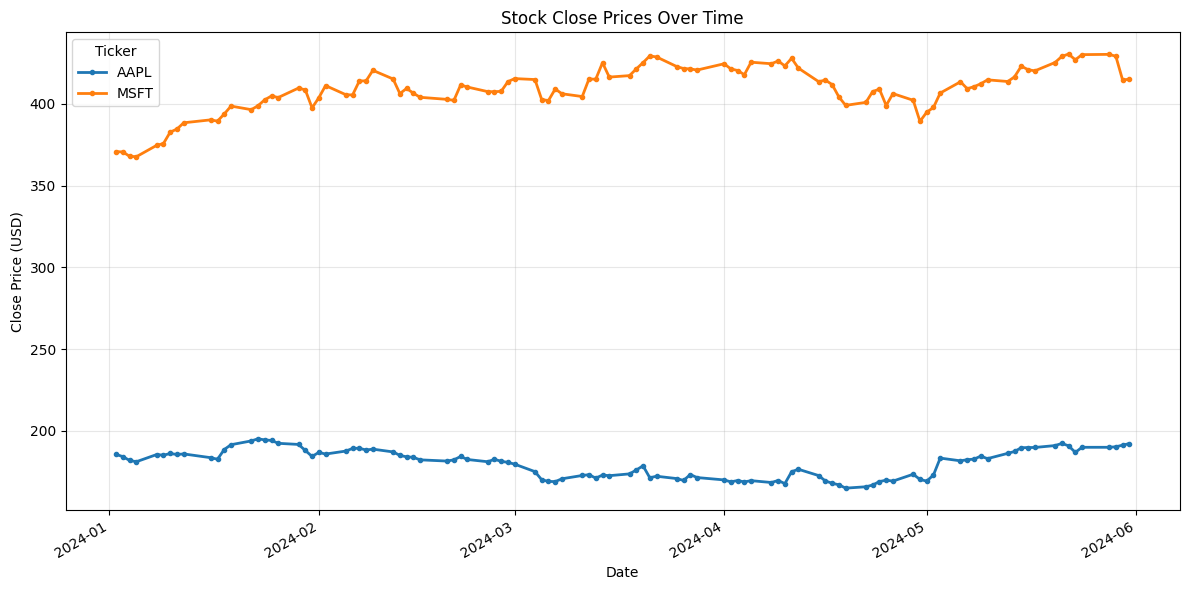

In [7]:
%matplotlib inline

import matplotlib.pyplot as plt

price_chart = (
    silver_df.sort_values("date")
    .pivot(index="date", columns="ticker", values="close")
)

ax = price_chart.plot(
    figsize=(12, 6),
    linewidth=2,
    marker="o",
    markersize=3,
    title="Stock Close Prices Over Time",
)

ax.set_xlabel("Date")
ax.set_ylabel("Close Price (USD)")
ax.legend(title="Ticker")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Gold stock performance summary

One row per ticker with start/end prices, total return, average daily return, volatility, and average volume metrics.

In [3]:
gold_performance_df = create_gold_performance_summary(silver_df)

print(f"Performance rows: {len(gold_performance_df):,}")
gold_performance_df

Performance rows: 2


,ticker,start_date,end_date,start_price,end_price,total_return,average_daily_return,volatility,average_volume,average_dollar_volume
0,AAPL,2024-01-02,2024-05-31,183.562164,190.598938,0.038335,0.000456,0.013878,6.061763e+07,1.089835e+10
1,MSFT,2024-01-02,2024-05-31,363.801514,408.706879,0.123434,0.001197,0.012483,2.146563e+07,8.756596e+09


## Gold moving averages

Daily prices with 20-day and 50-day moving averages per ticker.

In [4]:
gold_moving_averages_df = create_gold_moving_averages(silver_df)

print(f"Moving average rows: {len(gold_moving_averages_df):,}")
gold_moving_averages_df.head(10)

Moving average rows: 210


,date,ticker,adj_close,close,volume,ma_20,ma_50
0,2024-01-02,AAPL,183.562164,185.639999,82488700,NaN,NaN
1,2024-01-03,AAPL,182.187744,184.250000,58414500,NaN,NaN
2,2024-01-04,AAPL,179.873932,181.910004,71983600,NaN,NaN
3,2024-01-05,AAPL,179.152100,181.179993,62379700,NaN,NaN
4,2024-01-08,AAPL,183.483063,185.559998,59144500,NaN,NaN
5,2024-01-09,AAPL,183.067764,185.139999,42841800,NaN,NaN
6,2024-01-10,AAPL,184.106018,186.190002,46792900,NaN,NaN
7,2024-01-11,AAPL,183.512741,185.589996,49128400,NaN,NaN
8,2024-01-12,AAPL,183.839050,185.919998,40477800,NaN,NaN
9,2024-01-16,AAPL,181.574692,183.630005,65603000,NaN,NaN


## Gold volume summary

One row per ticker with min, max, total, and average volume metrics.

In [5]:
gold_volume_summary_df = create_gold_volume_summary(silver_df)

print(f"Volume summary rows: {len(gold_volume_summary_df):,}")
gold_volume_summary_df

Volume summary rows: 2


,ticker,start_date,end_date,min_volume,max_volume,total_volume,average_volume,average_dollar_volume
0,AAPL,2024-01-02,2024-05-31,34648500,163224100,6364851500,6.061763e+07,1.089835e+10
1,MSFT,2024-01-02,2024-05-31,11792300,47995300,2253891500,2.146563e+07,8.756596e+09


## Save gold tables

Write all gold outputs to `data/processed/gold/`.

In [6]:
GOLD_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

gold_performance_df.to_csv(PERFORMANCE_OUTPUT_PATH, index=False)
gold_moving_averages_df.to_csv(MOVING_AVERAGES_OUTPUT_PATH, index=False)
gold_volume_summary_df.to_csv(VOLUME_SUMMARY_OUTPUT_PATH, index=False)

print(f"Saved performance summary to {PERFORMANCE_OUTPUT_PATH}")
print(f"Saved moving averages to {MOVING_AVERAGES_OUTPUT_PATH}")
print(f"Saved volume summary to {VOLUME_SUMMARY_OUTPUT_PATH}")

Saved performance summary to C:\Users\bruce\OneDrive\Desktop\School\Personal Projects\financial-market-analytics-warehouse\data\processed\gold\gold_stock_prices.csv
Saved moving averages to C:\Users\bruce\OneDrive\Desktop\School\Personal Projects\financial-market-analytics-warehouse\data\processed\gold\gold_moving_averages.csv
Saved volume summary to C:\Users\bruce\OneDrive\Desktop\School\Personal Projects\financial-market-analytics-warehouse\data\processed\gold\gold_volume_summary.csv
